<a href="https://colab.research.google.com/github/sashapisterman/DSO510-Business-Analytics/blob/main/Assignment_2/DSO_510_Assignment_2_Pisterman_Sasha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 2 Assignment
## Exploratory Data Analytis with Python: Personal Loan Campaign Analysis

## Problem Statement

### Context

AllLife Bank is a US bank that has a growing customer base. The majority of these customers are liability customers (depositors) with varying sizes of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors).

A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio.

You as a Data scientist at AllLife bank have to build a model that will help the marketing department to identify the potential customers who have a higher probability of purchasing the loan.

### Objective

To predict whether a liability customer will buy personal loans, to understand which customer attributes are most significant in driving purchases, and identify which segment of customers to target more.

### Data Dictionary
* `ID`: Customer ID
* `Age`: Customer’s age in completed years
* `Experience`: #years of professional experience
* `Income`: Annual income of the customer (in thousand dollars)
* `ZIP Code`: Home Address ZIP code.
* `Family`: the Family size of the customer
* `CCAvg`: Average spending on credit cards per month (in thousand dollars)
* `Education`: Education Level. 1: Undergrad; 2: Graduate;3: Advanced/Professional
* `Mortgage`: Value of house mortgage if any. (in thousand dollars)
* `Personal_Loan`: Did this customer accept the personal loan offered in the last campaign? (0: No, 1: Yes)
* `Securities_Account`: Does the customer have securities account with the bank? (0: No, 1: Yes)
* `CD_Account`: Does the customer have a certificate of deposit (CD) account with the bank? (0: No, 1: Yes)
* `Online`: Do customers use internet banking facilities? (0: No, 1: Yes)
* `CreditCard`: Does the customer use a credit card issued by any other Bank (excluding All life Bank)? (0: No, 1: Yes)

## **Please read the instructions carefully before starting the project.**

This is a commented Jupyter IPython Notebook file in which all the instructions and tasks to be performed are mentioned.
* Blanks '_______' are provided in the notebook that
needs to be filled with an appropriate code to get the correct result. With every '_______' blank, there is a comment that briefly describes what needs to be filled in the blank space.
* Identify the task to be performed correctly, and only then proceed to write the required code.
* Fill the code wherever asked by the commented lines like "# write your code here" or "# complete the code". Running incomplete code may throw error.
* Please run the codes in a sequential manner from the beginning to avoid any unnecessary errors.

## Notebook Overview

This notebook performs an exploratory data analysis on the AllLife Bank personal loan dataset. The goal is to identify which customer characteristics are most associated with loan acceptance, in order to inform a more targeted marketing campaign and convert more current AllLife Bank liability customers into borrowers.

## Loading libraries

In [67]:
# this will help in making the Python code more structured automatically (good coding practice)
# %load_ext nb_black

import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data

import pandas as pd
import numpy as np

# Library to split data
from sklearn.model_selection import train_test_split

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)


## Loading the dataset

In [68]:
# from google.colab import drive
# drive.mount('/content/drive')

In [69]:
#from google.colab import files
#uploaded = files.upload()

In [70]:
Loan = pd.read_csv("Loan_Modelling.csv")

In [71]:
data = Loan.copy()

## Data Overview

The initial steps to get an overview of any dataset is to:
- Observe the first few rows of the dataset, to check whether the dataset has been loaded properly or not
- Get information about the number of rows and columns in the dataset
- Find out the data types of the columns to ensure that data is stored in the preferred format and the value of each property is as expected.
- Check the statistical summary of the dataset to get an overview of the numerical columns of the data

### View the first and last 5 rows of the dataset.

In [72]:
data.head()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [73]:
data.tail()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
4995,4996,29,3,40,92697,1,1.9,3,0,0,0,0,1,0
4996,4997,30,4,15,92037,4,0.4,1,85,0,0,0,1,0
4997,4998,63,39,24,93023,2,0.3,3,0,0,0,0,0,0
4998,4999,65,40,49,90034,3,0.5,2,0,0,0,0,1,0
4999,5000,28,4,83,92612,3,0.8,1,0,0,0,0,1,1


### Understand the shape of the dataset.

In [74]:
data.shape

(5000, 14)

### Check the data types of the columns for the dataset

In [75]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  5000 non-null   int64  
 1   Age                 5000 non-null   int64  
 2   Experience          5000 non-null   int64  
 3   Income              5000 non-null   int64  
 4   ZIPCode             5000 non-null   int64  
 5   Family              5000 non-null   int64  
 6   CCAvg               5000 non-null   float64
 7   Education           5000 non-null   int64  
 8   Mortgage            5000 non-null   int64  
 9   Personal_Loan       5000 non-null   int64  
 10  Securities_Account  5000 non-null   int64  
 11  CD_Account          5000 non-null   int64  
 12  Online              5000 non-null   int64  
 13  CreditCard          5000 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 547.0 KB


### Checking the Statistical Summary

In [76]:
data.describe()

,ID,Age,Experience,Income,ZIPCode,Family,CCAvg,Education,Mortgage,Personal_Loan,Securities_Account,CD_Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93169.257000,2.396400,1.937938,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,1759.455086,1.147663,1.747659,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,90005.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,0.700000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,1.500000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,2.500000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,10.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


*   Dataset was loaded properly with 5,000 rows and 14 columns.
*   There were no missing values.
*   The data types for the columns ZipCode, Education, Personal_Loan, Securities_Account, CD_Account, Online, and CreditCard will need to be changed because the values are categorical.
*   The statistical summary revealed a data error in the Experience column: negative values. These will be corrected by converting negative values to positive, as they will be assumed to be data entry errors.

### Let's drop the Booking_ID column first before we proceed forward

In [77]:
data = data.drop(columns=["ID"], errors='ignore')
data.shape

(5000, 13)

The ID column was dropped because it is a customer identifier and not relevant for analysis.

## Data Preprocessing

### Checking for Anomalous Values

In [78]:
# Let's map the values to 1: Undergrad; 2: Graduate 3: Advanced/Professional
data["Education"].replace(1, "Undergraduate", inplace=True)
data["Education"].replace(2, "Graduate", inplace=True)
data["Education"].replace(3, "Professional", inplace=True)
data["Education"].value_counts()

,count
Education,
Undergraduate,2096
Professional,1501
Graduate,1403


The values for the Education column were relabeled by category according to education level because it is an ordinal variable, and doing so will ensure data visualization is easy to read and understand.


* Treating the negative values of Experience: We assume that these negative signs here are data input errors, so we will replace them with positive signs

In [79]:
# checking if experience <0
data[data["Experience"] < 0]["Experience"].unique()

array([-1, -2, -3])

In [80]:
# Correcting the experience values
data["Experience"].replace(-1, 1, inplace=True)
data["Experience"].replace(-2, 2, inplace=True)
data["Experience"].replace(-3, 3, inplace=True)

The data error in the Experience column was corrected by converting the negative values to positive values. The assumption is that the negative values were a data entry error.

### Feature Engineering

In [81]:
data["ZIPCode"].nunique()

467

In [82]:
data["ZIPCode"] = data["ZIPCode"].astype(str)
print(
    "Number of unique values if we take first two digits of ZIPCode: ",
    data["ZIPCode"].str[0:2].nunique(),
)
data["ZIPCode"] = data["ZIPCode"].str[0:2]

data["ZIPCode"] = data["ZIPCode"].astype("category")

Number of unique values if we take first two digits of ZIPCode:  7


In order to simplify analysis and make data visualization easier to interpret, we group zip codes by the first two digits. This allows grouping by region, while allowing analysis to reveal meaningful insights about geography.

In [83]:
cat_cols = [
    "Education",
    "Personal_Loan",
    "Securities_Account",
    "CD_Account",
    "Online",
    "CreditCard",
    "ZIPCode",
]
data[cat_cols] = data[cat_cols].astype("category")

Changed the data types for the columns ZipCode, Education, Personal_Loan, Securities_Account, CD_Account, Online, and CreditCard to 'category' so that Python treats these columns as categorical variables rather than continuous variables. This will allow the correct analyses to be performed.

## Exploratory Data Analysis

### Univariate Analysis

In [84]:
def histogram_boxplot(data, feature, figsize=(12, 7), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (12,7))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a star will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, palette="winter"
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [85]:
# function to create labeled barplots


def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

#### Observations on Age

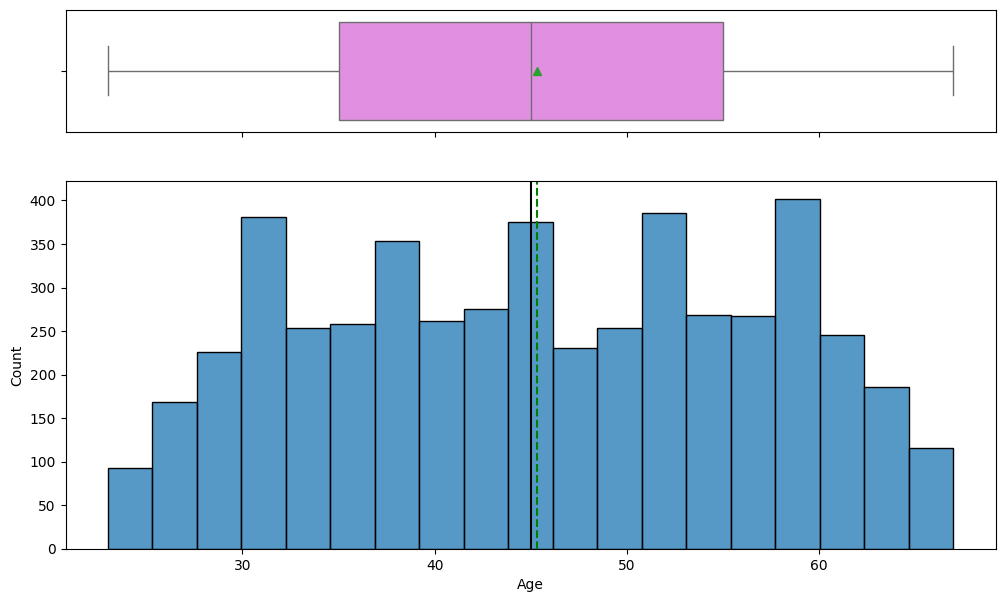

In [86]:
histogram_boxplot(data, "Age")

The box plot shows that there are no outliers. The histogram shows that the data is spread out, but that the majority of customers fall within the 30 to 60 year old range. Both the mean and the median hover around age 45, signifying that distribution is symmetric.

#### Observations on Experience

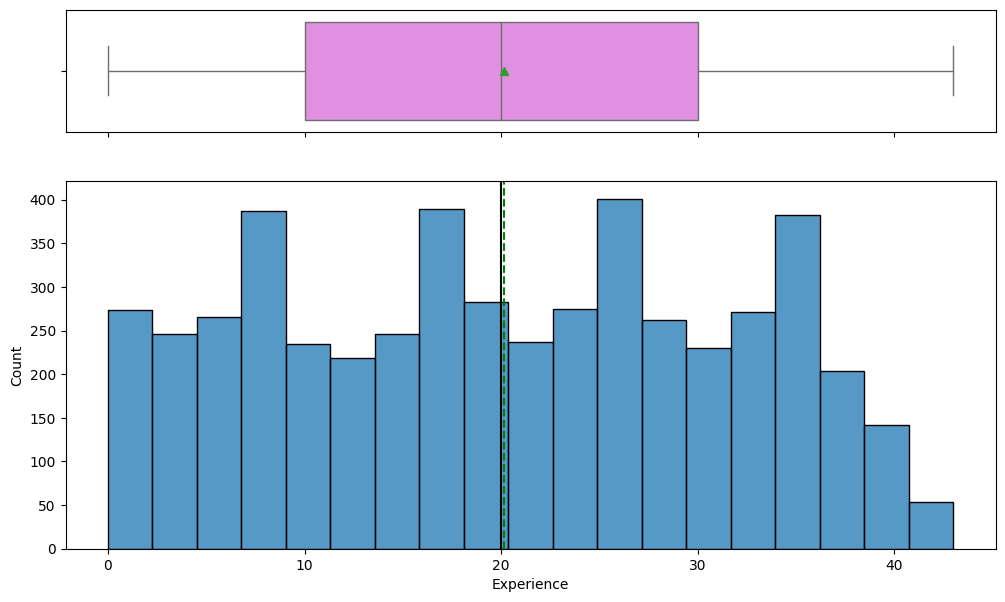

In [87]:
histogram_boxplot(data,"Experience")

The box plot shows that there are no outliers. The histogram shows that the data is spread out, but that the majority of customers fall between 5 and 35 years of experience. Both the mean and median are around 20 years of experience, thus making the data symmetric. This mirrors the Age distribution closely.

#### Observations on Income

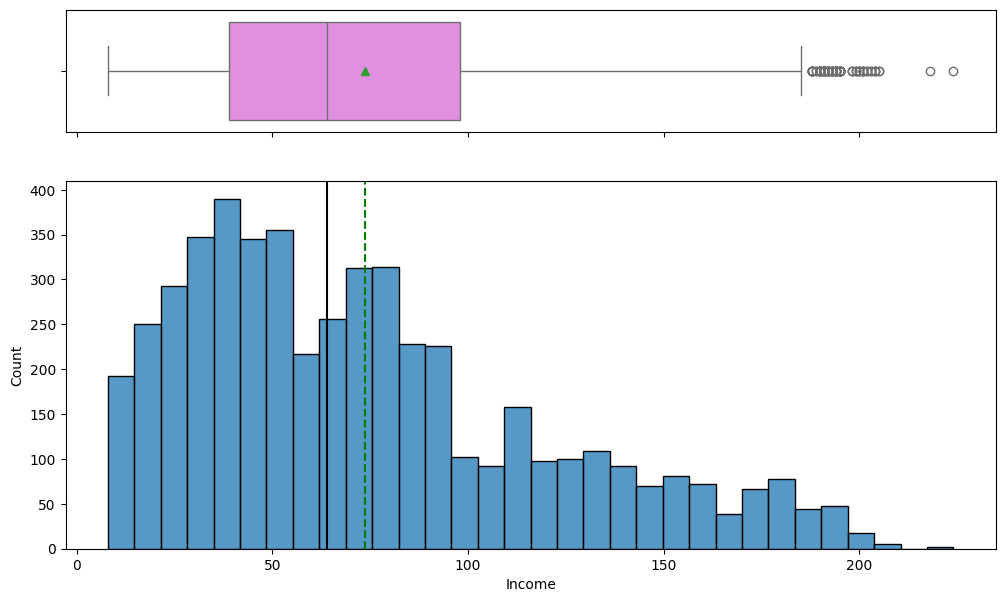

In [88]:
histogram_boxplot(data,"Income")

The box plot is concentrated towards the left, with outliers on the right side. There are two clusters of outliers, and then two individual outliers further right. The histogram mirrors this, as it is right-skewed, with the majority of customers falling between approximately 25,000 and 95,000 dollars. There is a small concentration sitting beyond the 150,000 dollar mark, and an even smaller concentration sitting beyond the 200,000 dollar mark. The median is approximately 53,000 dollars and the mean is approximately 55,000 dollars. The majority of the bank's customer base falls in the lower to middle income category, with a few higher-earning individuals.

#### Observations on CCAvg

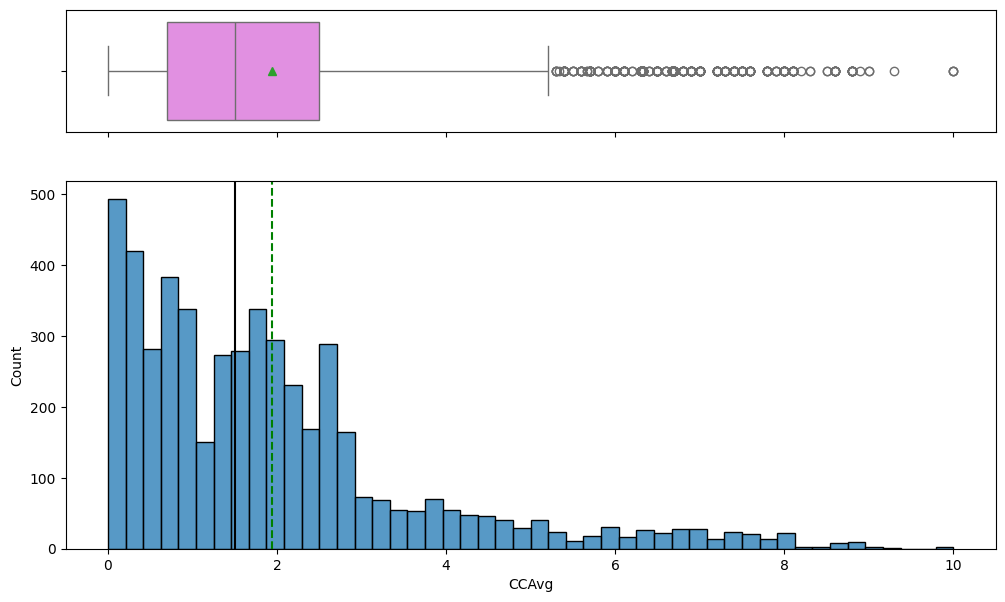

In [89]:
histogram_boxplot(data,"CCAvg")

The box plot is concentrated towards the left, with a few clusters of outliers on the right side. The histogram mirrors this, as it is right-skewed, with the majority of customers having less than approximately 3,000 dollars of credit card spend per month. There is a long tail beyond the 3,000 dollar mark, going up to 10,000 dollars. The median is approximately 1,700 dollars and the mean is approximately 2,000 dollars. The majority of the bank's customer base fall into the lower monthly credit card spend category, with a few higher-spending individuals. This mirrors the customer's income levels, thus possibly illustrating that the low to mid-level earners have a lower monthly credit card spend than the higher earners.

#### Observations on Mortgage

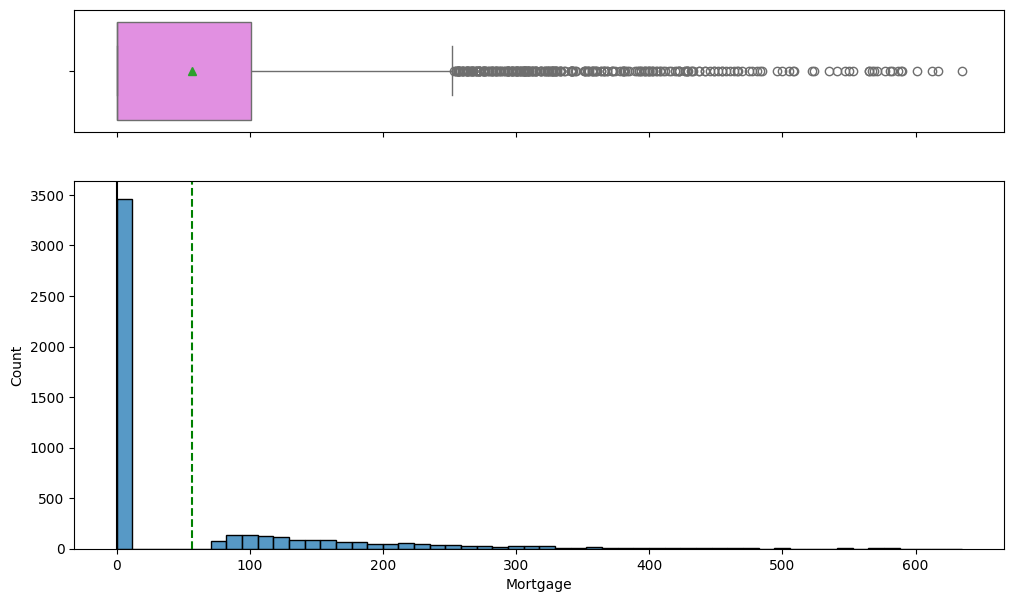

In [90]:
histogram_boxplot(data,"Mortgage")

The box plot is concentrated towards the left tail, with a concentration of clusters on the right side. The histogram shows that the highest concentration of customers have a mortgage between 0 and approximately 10,000 dollars. There is a cluster that is spread out between 90,000 and 200,000 dollars, with a few going up to the 600,000 dollar mark, The mean is approximately 50,000 dollars and the median is 0, which signifies that the majority of the bank's customers are not homeowners.

#### Observations on Family

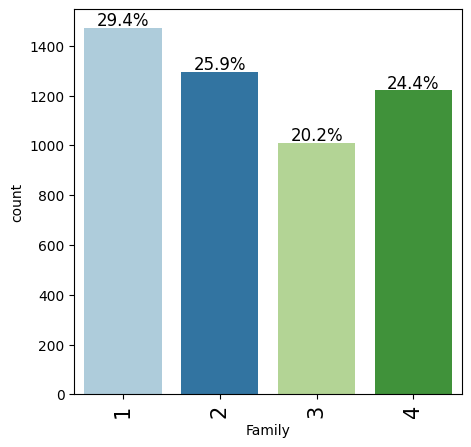

In [91]:
labeled_barplot(data, "Family", perc=True)

Family size is pretty evenly spread out. The highest concentrartion at approximately 30% are single-person households, followed by approximately 26% with a family size of 2, then approximately 24% with a family size of 4, and approximately 20% with a family size of 3.

#### Observations on Education

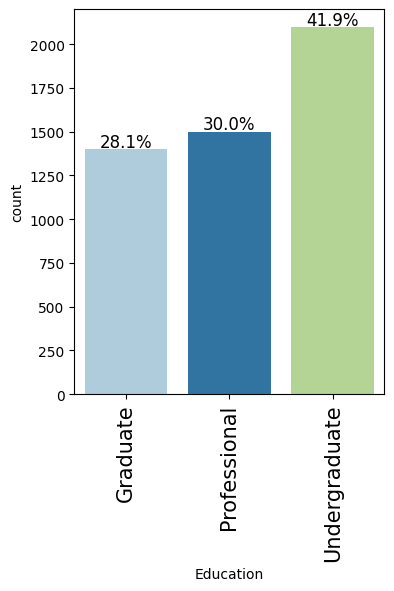

In [92]:
labeled_barplot(data,"Education",perc=True)

AllLife Bank's customer education levels are comprised of approximately 42% having undergraduate degrees (n = 2,096), 30% have professional degrees (n = 1,501), and approximately 28% have graduate degrees (n = 1,403).

#### Observations on Securities_Account

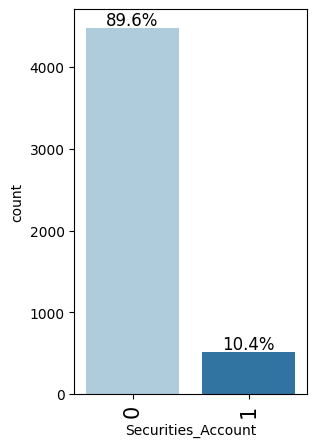

In [93]:
labeled_barplot(data,"Securities_Account",perc=True)

Approximately 90% of the bank's customers do not have securities accounts (n = 4,478). Only approximately 10% do (n = 522).

#### Observations on CD_Account

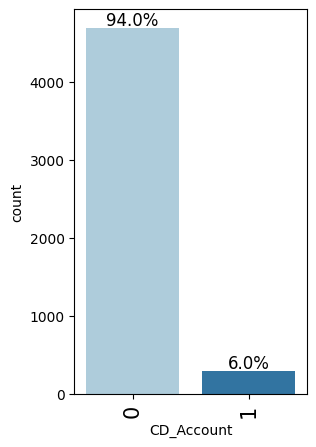

In [94]:
labeled_barplot(data,"CD_Account",perc=True)

Approximately 94% of the bank's customers do not have CD accounts (n = 4,698). Only approximately 6% do (n = 302).

#### Observations on Online

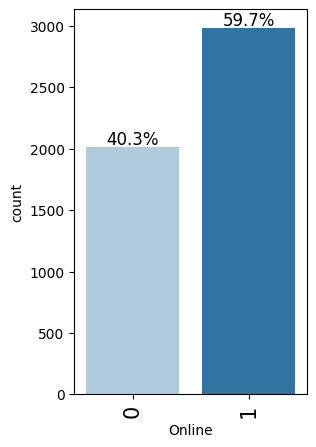

In [95]:
labeled_barplot(data,"Online",perc=True)

Approximately 60% of the bank's customers do have online banking accounts (n = 2,984). And approximately 40% do not (n = 2,016).

#### Observation on CreditCard

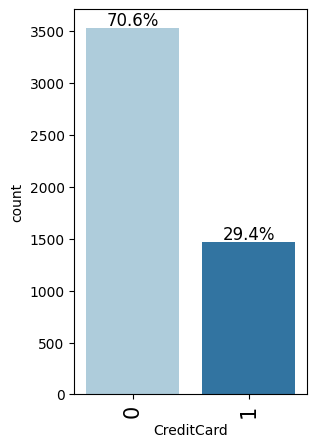

In [96]:
labeled_barplot(data,"CreditCard",perc=True)

Approximately 71% of the bank's customers do not have an AllLife Bank credit card (n = 3,530). However, approximately 29% do (n = 1,470).

#### Observation on ZIPCode

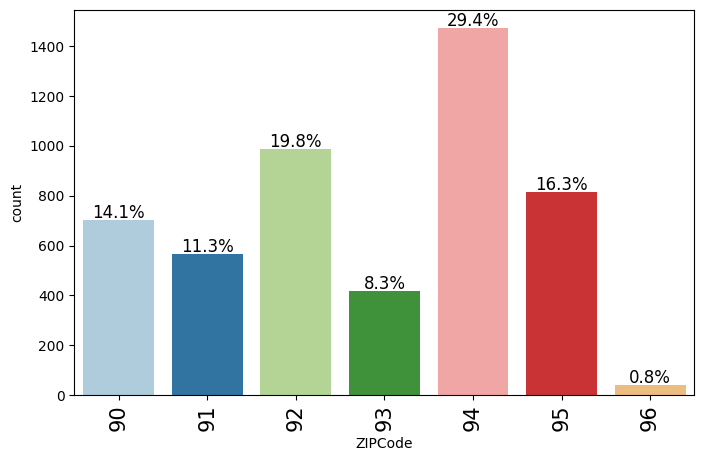

In [97]:
labeled_barplot(data,"ZIPCode",perc=True)

The highest concentration of AllLife Bank's customers, approximately 29% (n = 1,472), are located in the 94 region. The second largest concentration are in the 92 region, approximately 20% (n = 988). The remaining customers are spread out through the 90, 91, 93, and 95 regions, with only approximately 1% (n = 40) in the 96 region.

### Bivariate Analysis

In [98]:
def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
    plt.show()

In [99]:
### function to plot distributions wrt target


def distribution_plot_wrt_target(data, predictor, target):

    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    target_uniq = data[target].unique()

    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(data=data, x=target, y=predictor, ax=axs[1, 0], palette="gist_rainbow")

    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    plt.tight_layout()
    plt.show()

#### Correlation check

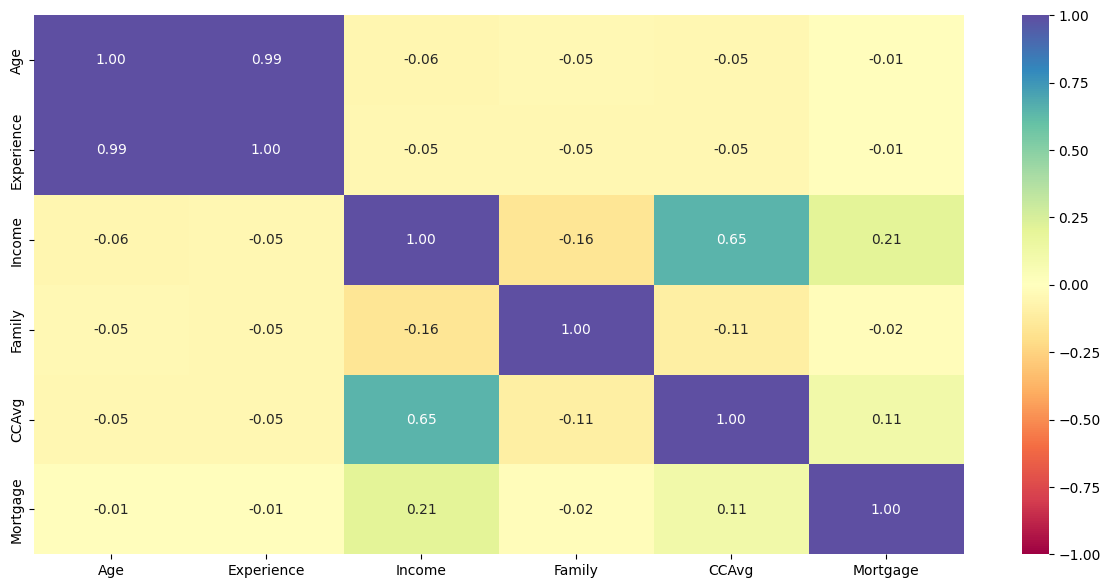

In [100]:
plt.figure(figsize=(15, 7))
sns.heatmap(data.select_dtypes(include=["float64", "int64"]).corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

*   There is a strong correlation of 0.99 between Age and Experience, which signifies multicollinearity. Due to this, these variables would essentially be providing a model the same information. Thus, we may decide to drop one of these variables in future analyses.
*   There is also a correlation of 0.65 between Income and CCAvg, which shows a relationship between higher earners having a higher monthly credit card spend. This is a general tendency, as some lower earners may also have higher monthly credit card spending and be carrying debt.

#### Let's check how a customer's interest in purchasing a loan varies with their education

Personal_Loan     0    1   All
Education                     
All            4520  480  5000
Professional   1296  205  1501
Graduate       1221  182  1403
Undergraduate  2003   93  2096
------------------------------------------------------------------------------------------------------------------------


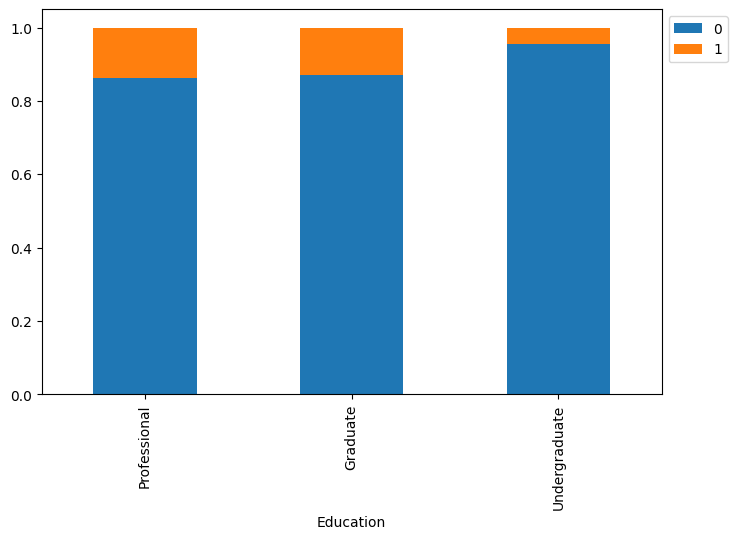

In [101]:
stacked_barplot(data, "Education", "Personal_Loan")

Customers with professional degrees are most likely to accept a personal loan offer at 13.6%, followed by customers with graduate degrees at 12.9%. The group least likely to accept a personal loan offer at 4.4% are customers with undergraduate degrees. This could signify that customers with more advanced degrees are more likely to take out personal loans due to having a higher income, level of financial literacy, comfort with debt, or something else.

#### Personal_Loan vs Family

Personal_Loan     0    1   All
Family                        
All            4520  480  5000
4              1088  134  1222
3               877  133  1010
1              1365  107  1472
2              1190  106  1296
------------------------------------------------------------------------------------------------------------------------


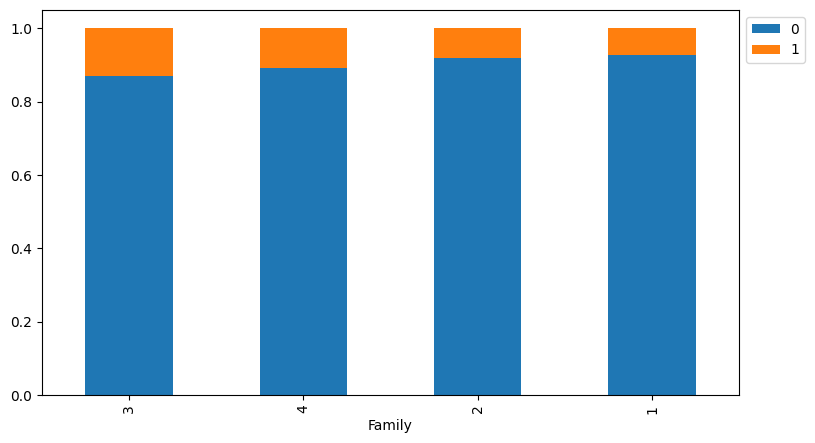

In [102]:
stacked_barplot(data,"Family","Personal_Loan")

Customers with a family size of 3 are most likely to accept a personal loan offer at 13.1%, followed by customers with family size of 4 at 10.9%, then a family size of 2 at 8.2%, and lastly a family size of 1 at 7.3%. This could signify that customers with larger family sizes are more likely to take out personal loans due to having higher overall expenses such as childcare, tuition, home improvement costs, elderly care, or something else.

#### Personal_Loan vs Securities_Account

Personal_Loan          0    1   All
Securities_Account                 
All                 4520  480  5000
0                   4058  420  4478
1                    462   60   522
------------------------------------------------------------------------------------------------------------------------


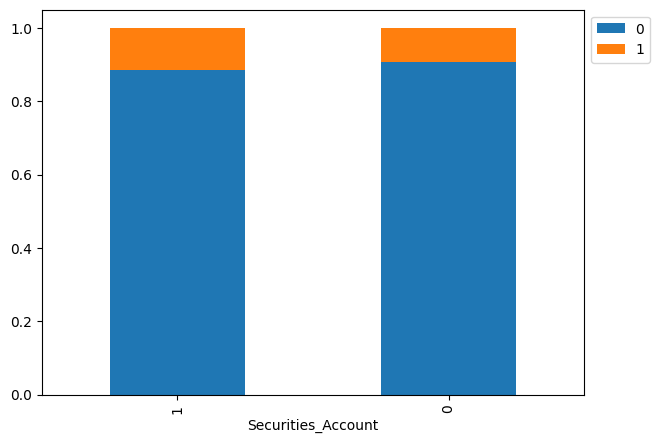

In [103]:
stacked_barplot(data,"Securities_Account","Personal_Loan")

Customers with a securities account have a slightly higher acceptance rate of personal loans at 11.5%, compared to those who do not have a securities account at 9.4%. Thus, securities account holders may accept personal loan offers at a higher rate, but the difference is not substantial enough to make this variable a strong predictor.

#### Personal_Loan vs CD_Account

Personal_Loan     0    1   All
CD_Account                    
All            4520  480  5000
0              4358  340  4698
1               162  140   302
------------------------------------------------------------------------------------------------------------------------


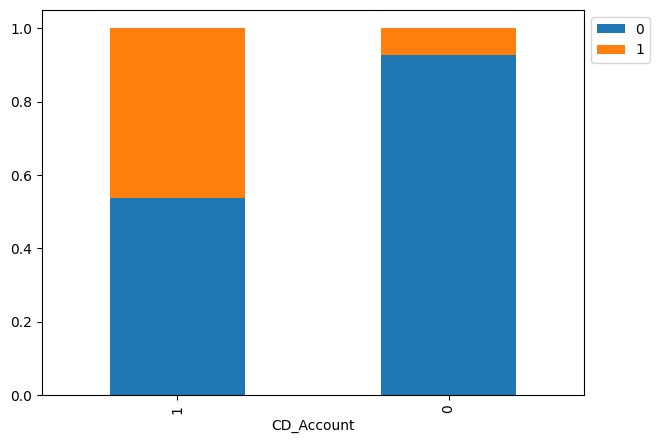

In [104]:
stacked_barplot(data,"CD_Account","Personal_Loan")

Customers with a CD account have a much higher acceptance rate of personal loans at 46.3%, compared to those who do not have a CD account at 7.2%. Thus, whether or not a customer is a CD account holder is a strong predictor of whether they will accept a personal loan offer. Although this group is smaller, their higher acceptance rate makes them a high value target segment

#### Personal_Loan vs Online

Personal_Loan     0    1   All
Online                        
All            4520  480  5000
1              2693  291  2984
0              1827  189  2016
------------------------------------------------------------------------------------------------------------------------


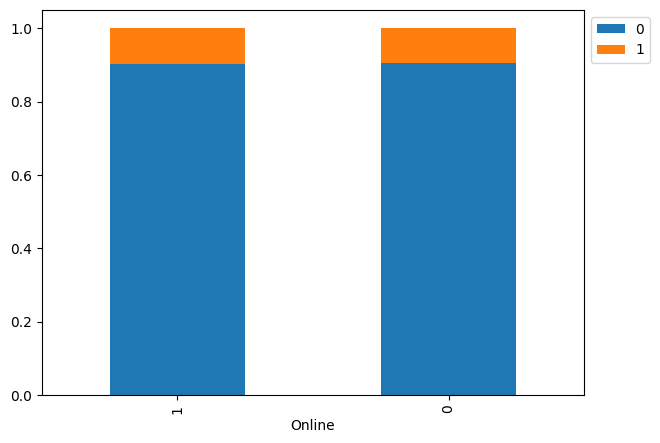

In [105]:
stacked_barplot(data,"Online","Personal_Loan")

Customers with an online account have an acceptance rate of personal loans at 9.8%, which is very similar to customers who do not have an online account at 9.4%. Online banking usage does not seem to be a predictor of whether or not a customer will accept a personal loan.

#### Personal_Loan vs CreditCard

Personal_Loan     0    1   All
CreditCard                    
All            4520  480  5000
0              3193  337  3530
1              1327  143  1470
------------------------------------------------------------------------------------------------------------------------


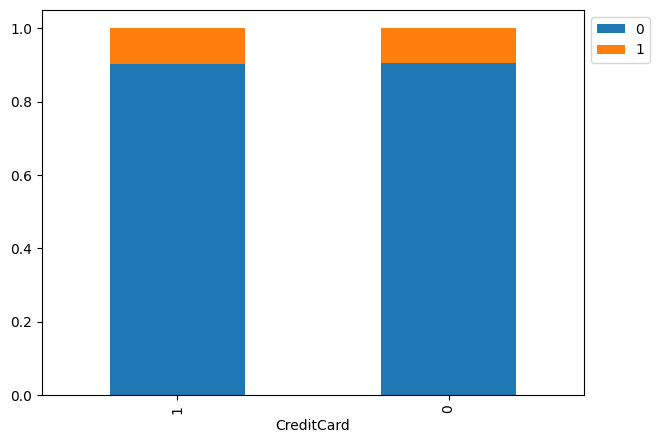

In [106]:
stacked_barplot(data,"CreditCard","Personal_Loan")

Customers with an AllLife Bank credit card have an acceptance rate of personal loans at 9.7%, which is very similar to customers who do not have a credit card at 9.5%. Being a credit card holder does not seem to be a predictor of whether or not a customer will accept a personal loan.

#### Personal_Loan vs ZIPCode

Personal_Loan     0    1   All
ZIPCode                       
All            4520  480  5000
94             1334  138  1472
92              894   94   988
95              735   80   815
90              636   67   703
91              510   55   565
93              374   43   417
96               37    3    40
------------------------------------------------------------------------------------------------------------------------


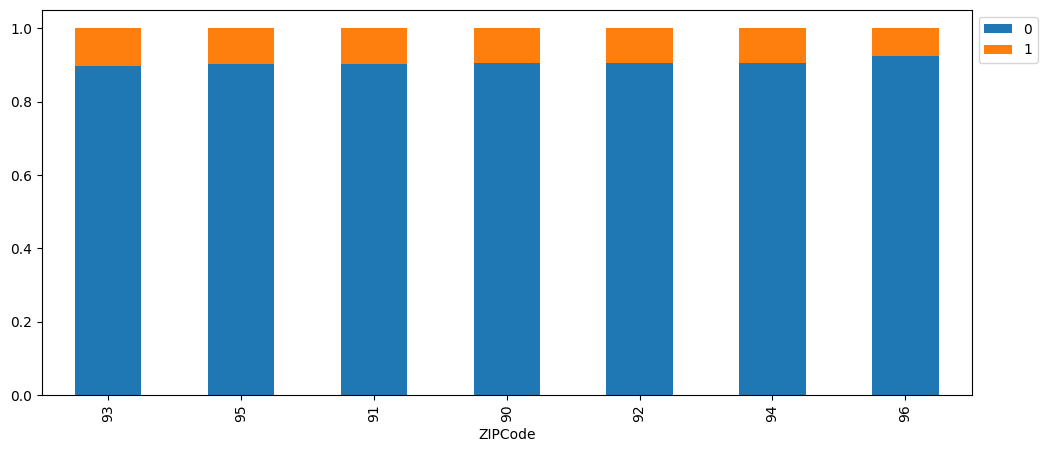

In [107]:
stacked_barplot(data,"ZIPCode","Personal_Loan")

Customer's geographic location shows a very similar range in acceptance rates across all seven regions:


*   93: 10.3%
*   95: 9.8%
*   91: 9.7%
*   90: 9.5%
*   92: 9.5%
*   94: 9.4%
*   96: 7.5%

The widest gap is between 93 and 96, however, region 96 only contains 40 customers total and only 3 customers accepting personal loan offers.









#### Let's check how a customer's interest in purchasing a loan varies with their age

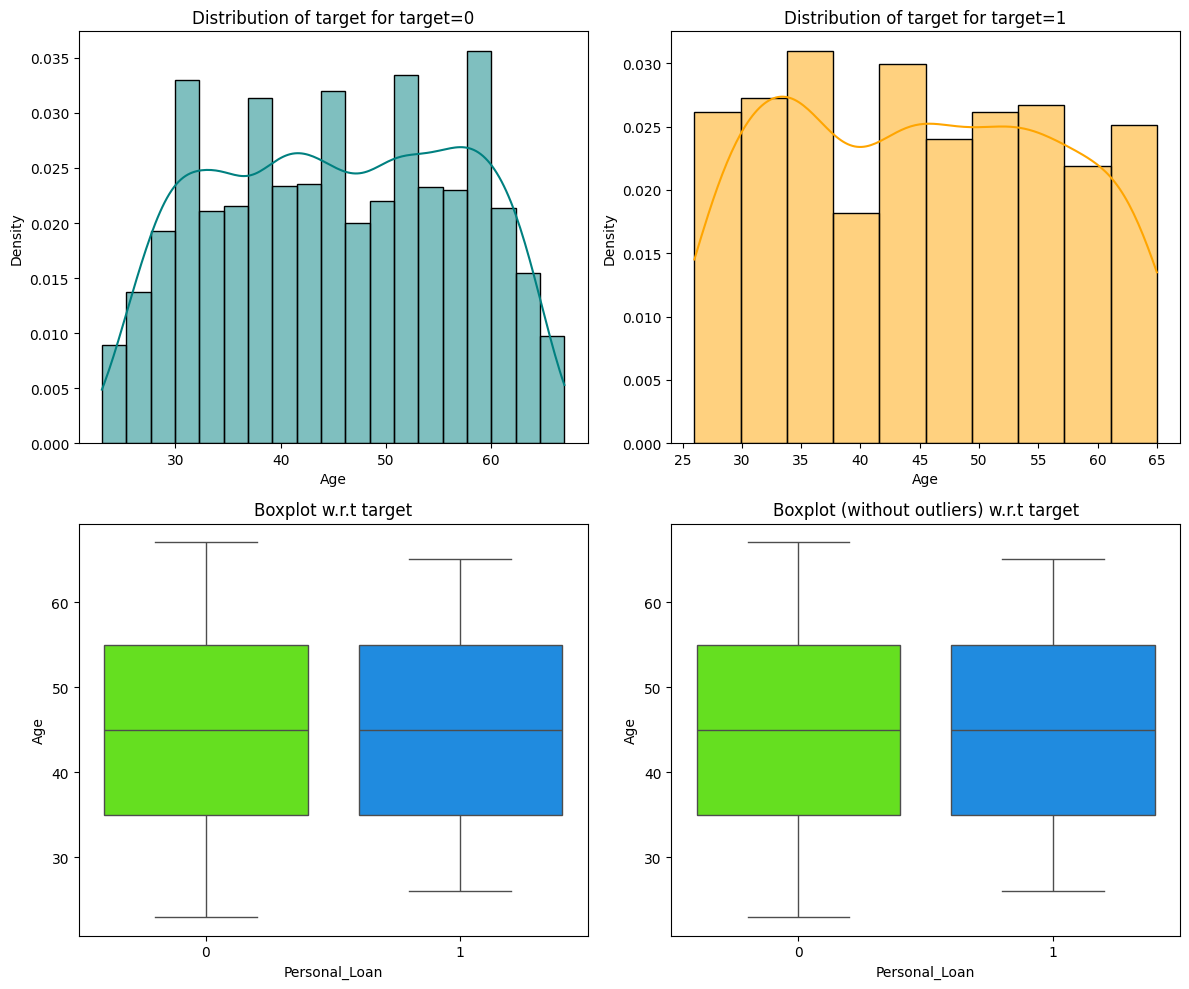

In [108]:
distribution_plot_wrt_target(data, "Age", "Personal_Loan")

Loan acceptors show a slight concentration between ages 35-45, while non-acceptors are more evenly spread across the 30-60 age range. However, since both groups share a similar median age of approximately 45, age alone may not be a strong predictor of loan acceptance.

#### Personal Loan vs Experience

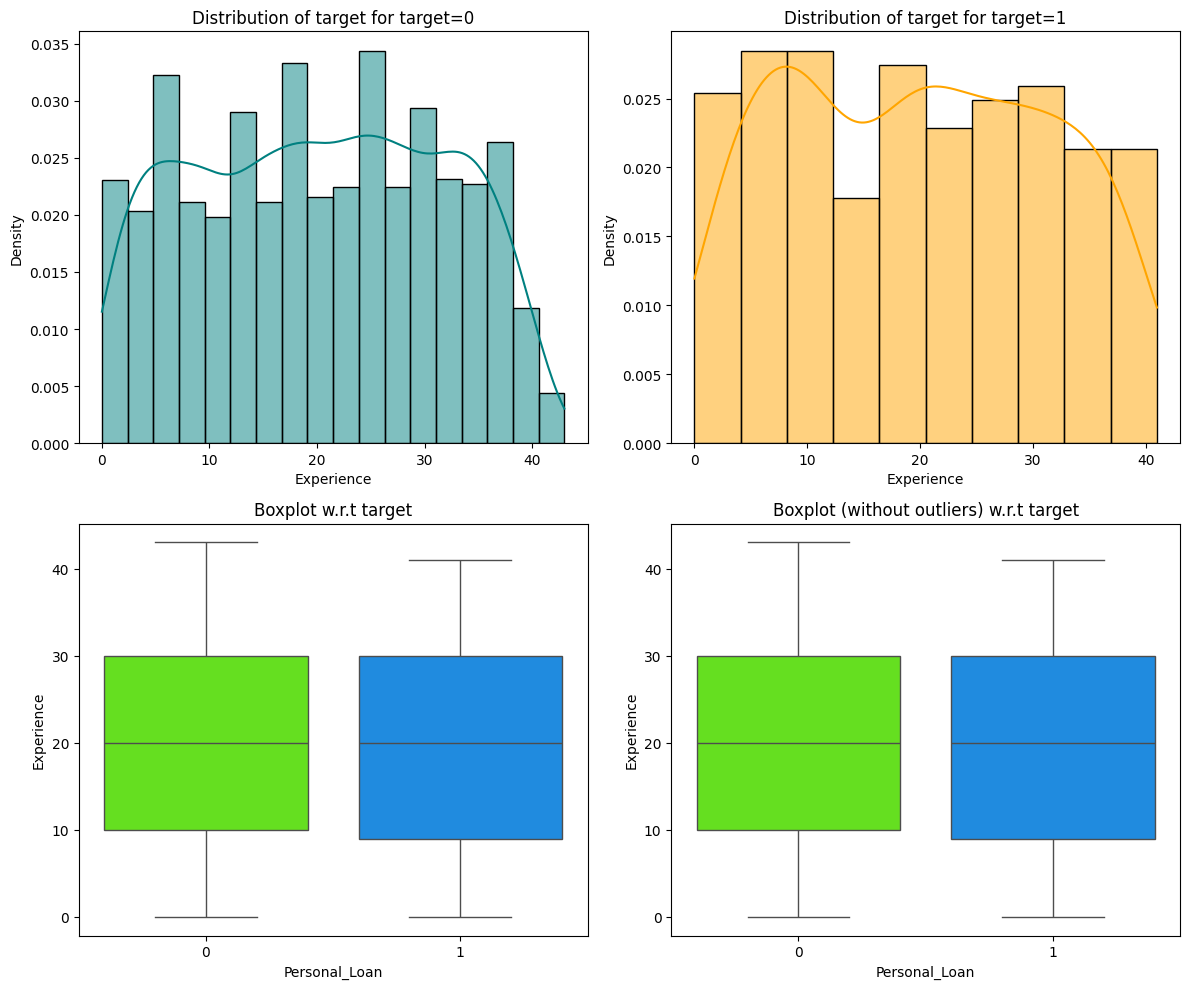

In [109]:
distribution_plot_wrt_target(data,"Experience","Personal_Loan")

Loan acceptors and non-acceptors are both evenly spread across the 0 to 40 years of experience range. In addition, both groups share a similar median of approximately 20 years of experience, thus signifying that years of experience may not be a strong predictor of loan acceptance.

#### Personal Loan vs Income

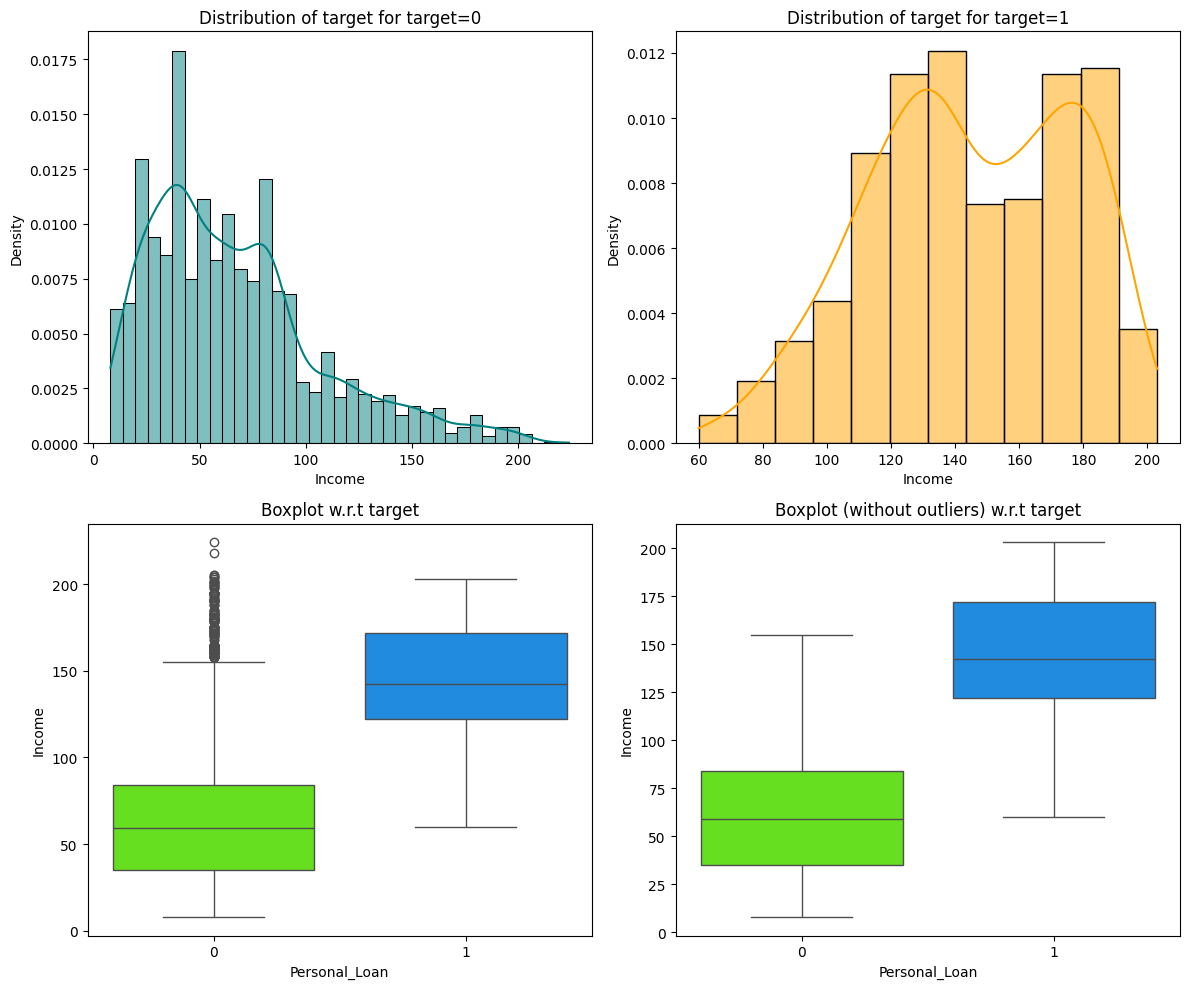

In [110]:
distribution_plot_wrt_target(data,"Income","Personal_Loan")

Loan acceptors show a much higher concentration at income levels above approximately 110,000 dollars, while non-acceptors show a much higher concentration below approximately 95,000 dollars. The medians also signify a vast difference in acceptance rates with loan acceptors having a median income of 125,000 dollars versus non-acceptors median income of 55,000 dollars.

Bank customers that accept the personal loan offer tend to fall within the higher income range, thus making this variable a strong predictor.

#### Personal Loan vs CCAvg

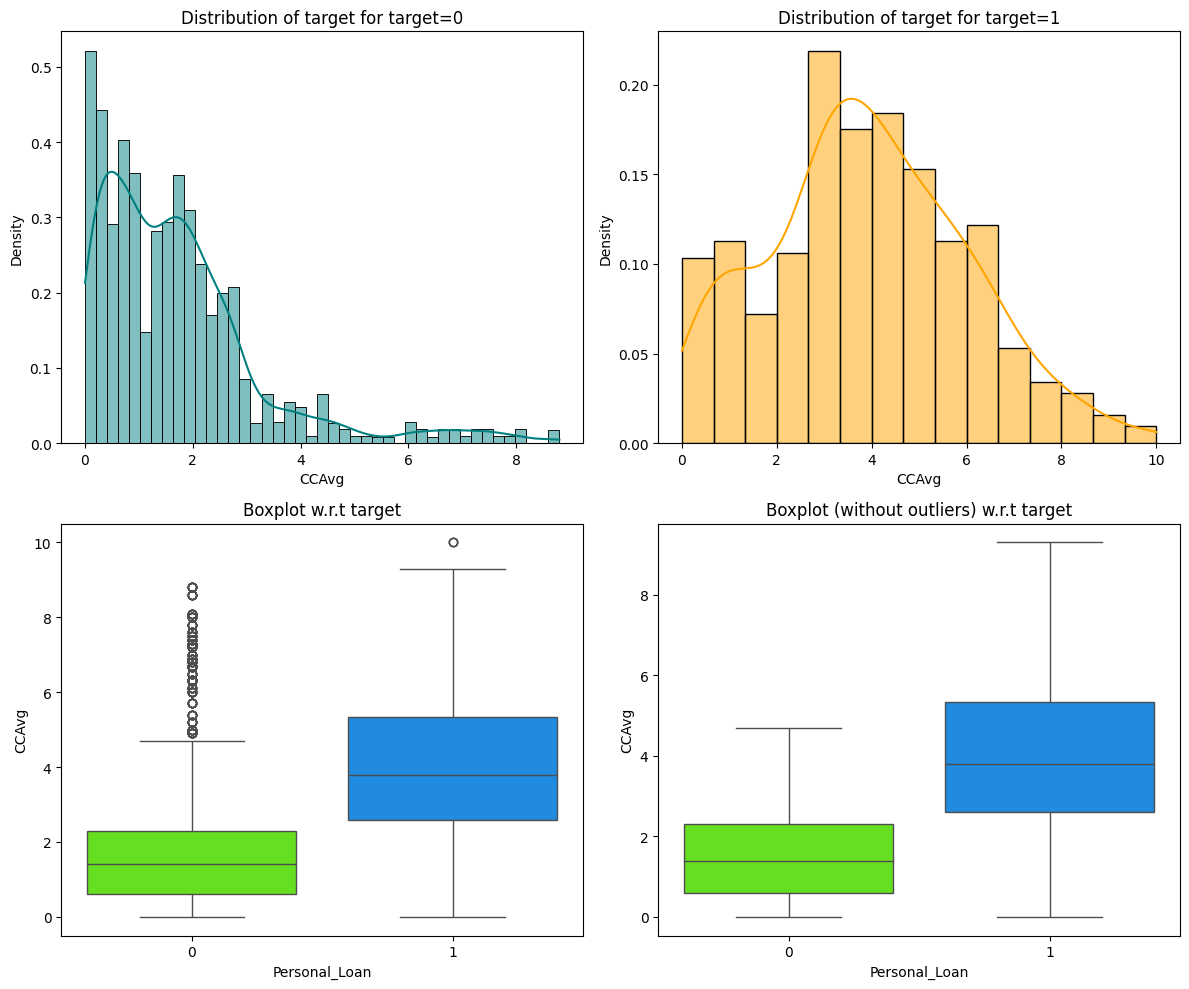

In [111]:
distribution_plot_wrt_target(data,"CCAvg","Personal_Loan")

Loan acceptors show a higher concentration at a monthly credit card spend above approximately 2,700 dollars, while non-acceptors show a higher concentration below approximately 2,500 dollars. The medians also signify a vast difference in acceptance rates with loan acceptors having a median monthly credit card spend of approximately 3,800 dollars versus non-acceptors' monthly credit card spend of approximately 1,500 dollars.

Bank customers that accept the personal loan offer tend to be higher monthly credit card spenders, thus making this variable a strong predictor.

## Data Preprocessing (contd.)

### Outlier Detection

In [112]:
Q1 = data.quantile(0.25, numeric_only=True)
Q3 = data.quantile(0.75, numeric_only=True)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [113]:
((data.select_dtypes(include=["float64", "int64"]) < lower)
    |(data.select_dtypes(include=["float64", "int64"]) > upper)
).sum() / len(data) * 100

,0
Age,0.00
Experience,0.00
Income,1.92
Family,0.00
CCAvg,6.48
Mortgage,5.82


Outlier detection showed outliers in the following variables: Income, CCAvg, and Mortgage. These outliers will not be removed because they represent important customer segments that have shown to be strong predictors of potential personal loan acceptance.

## Actionable Insights and Business Recommendations

### What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (Use the EDA above to drive your business recommendations).

Data analyses were used to identify which segments of AllLife Bank's customers are most likely to convert into personal loan customers. The analysis identified significant predictors of personal loan acceptance as well as variables that showed no prediction. of personal loan acceptance. The recommendations that follow are based on these analyses and outline the customer segments that are most likely to convert.

### Conclusions:
* CD Account is the strongest predictor. CD Account holders accept personal loans at 46.3% versus 7.2% for non-holders.
* Income is the second strongest predictor. Customers who accepted had a median income of 125k dollars versus 55k dollars for non-acceptors.
* CCAvg is also a strong predictor. Customers with a median monthly credit card spend of 3,800 dollars accept personal loans versus 1,500 dollars.
* Education can be a predictor. Customers with Professional/Graduate degrees accept personal loans at significantly higher rates of 13.6% and 12.9% versus customers with only Undergraduate degrees at 4.4%.
* Family Size can also be a predictor. Customers with a family size of 3 accepted at 13.1%, followed by customers with a family size of 4 at 10.9%, then a family size of 2 at 8.2%, and lastly a family size of 1 at 7.3%.

### Recommendations:
*  Allocate the highest priority outreach to customers that are CD account holders, as nearly half will potentially convert. Have personal bankers reach out with personalized emails to these customers.
* Allocate a digital advertising budget that targets higher income customers that are CD account holders. This combined segment represents the highest probability of conversion.
* Develop an email marketing campaign targeting customers with both higher incomes and higher monthly credit card spend to convert this segment.
* Develop a secondary email marketing campaign targeting customers with professional and graduate degrees, as well as those with a family size of 3 or 4.
* Online banking usage and credit card holder status showed almost no difference in acceptance rates and should not be used as standalone targeting criteria.

##AI Usage Disclosure
AI assistance (Claude, Anthropic) was used in completing this assignment. Rather than requesting completed code or answers, the following prompt was used to guide the interaction: "I do not want you to do the assignment for me. I want you to walk me through each step and teach me how to do it to make sure that I understand not only how to do it, but the concept behind it." Claude was used as a teaching tool to explain concepts before writing code, interpret chart outputs, understand error messages, and think through analytical conclusions. All code, observations, markdown cells, conclusions, and recommendations were written by me based on my own understanding developed through this guided learning process. Claude did not write any portion of the notebook directly.